# Agglomerative (Hierarchical) Clustering

## Table of Contents

### 1. What is Agglomerative Clustering?

### 2. Agglomerative Clustering in Scikit-Learn

### 3. Evaluation of Clustering

### 4. Important Considerations for Agglomerative Clustering

## 1. What is Agglomerative Clustering?

A hierarchical clustering method that builds a tree (dendrogram) of clusters.

“Agglomerative” means bottom-up:

- Start with each point as its own cluster

- Iteratively merge the two closest clusters

- Repeat until all points are merged into one cluster or a desired number of clusters is reached

Result: a dendrogram (tree diagram showing cluster merges)

Goal: Understand **hierarchical relationships** between data points.

**Unlike K-Means, it does not require random initialization, so results are deterministic given the same parameters**


## 2. Agglomerative Clustering in Scikit-Learn

The name of the class for Agglomerative Clustering in Scikit-Learn
  **sklearn.cluster.AgglomerativeClustering**


## **AgglomerativeClustering Parameters Explained (scikit-learn)**

### **Most Important Parameters**

### `1. n_clusters`
-  The number of clusters to form. Determines how many groups the algorithm will merge the points into.  
- default=2
- If you also set `distance_threshold`, this parameter is ignored because merging is stopped based on distance rather than cluster count.  

### `2.metric`

Distance metric used to calculate similarity between points. Determines which points are “close” to each other.

**Common Options:**  
  - `euclidean` (default) → straight-line distance; most common for numeric features.  
  - `manhattan` → sum of absolute differences; robust to outliers.  
  - `cosine` → measures angle between vectors; useful for text embeddings   

### `3. linkage`

Determines how the distance between **clusters** is computed during merging  

**Options**  

  - `ward` (default) → merges clusters that **minimize the variance** of combined cluster; produces compact, round clusters. Only works with Euclidean distance

  - `complete` → distance = **maximum distance** between any two points across clusters. Produces **tight, well-separated clusters**

  - `average` → distance = **average of all pairwise distances** between points in the two clusters. Balanced behavior between single and complete linkage

Different linkages affect **cluster shape, size and sensitivity to noise**  




**Important rules and constraints:**
- If `linkage="ward"`, **only `"euclidean"` is allowed**  
  (because Ward’s method relies on variance minimization).

Choice of metric affects which points are considered “close” and thus which clusters are merged first  


### **Occasionally Used Parameters**

### `distance_threshold`

Stops merging clusters when the distance between clusters exceeds this threshold.

**Options:** float (default=None)  

- Useful when you want a **hierarchy** and do not know the number of clusters in advance

- Example: `distance_threshold=5` → any clusters separated by more than 5 units will **not merge**, creating more clusters automatically

- If set, `n_clusters` is ignored  


### `compute_full_tree`

Determines whether the full clustering tree is computed. Needed for dendrogram plotting.  

**Options**  (default=auto)
  - `auto` → computes full tree only when needed (e.g., small datasets or dendrogram)
  - `True` → always compute the full tree; useful for plotting dendrograms  
  - `False` → skips computing full tree to save memory and computation for large datasets

### Apply Agglomerative Clustering to a simple Dataset

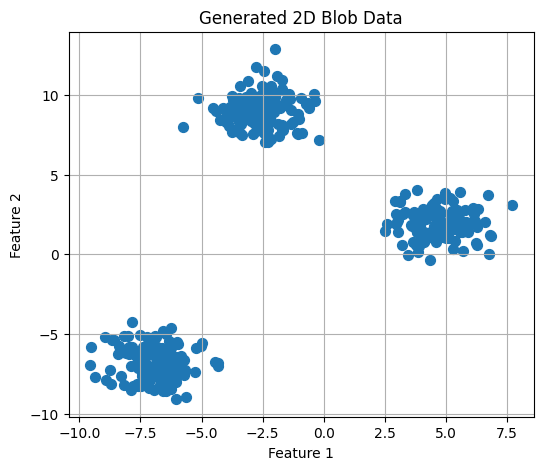

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
from sklearn.metrics import silhouette_score

# Generate 400 points in 2D, 3 clusters
X, y = make_blobs(n_samples=400, n_features=2, centers=3, random_state=42)

# Plot the raw data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated 2D Blob Data")
plt.grid(True)
plt.show()

Silhouette Score: 0.8458787585795497


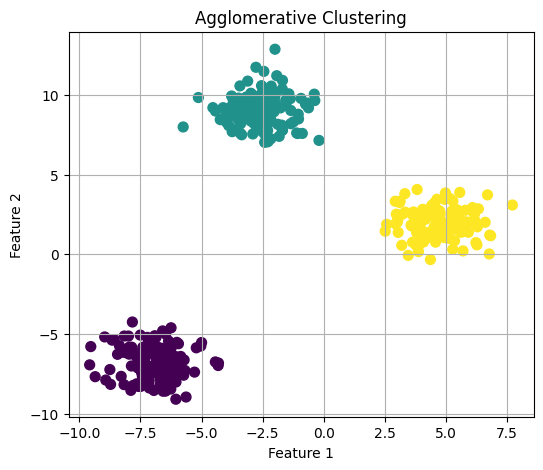

In [38]:
# Create the model
agg = AgglomerativeClustering(
    n_clusters=3,       # we know 3 clusters exist
    metric='euclidean',  # distance metric
    linkage='ward'          # linkage method
)

# Fit and predict cluster labels
labels = agg.fit_predict(X)
score = silhouette_score(X, labels)
print("Silhouette Score:", score)
# Plot clustered data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Agglomerative Clustering")
plt.grid(True)
plt.show()

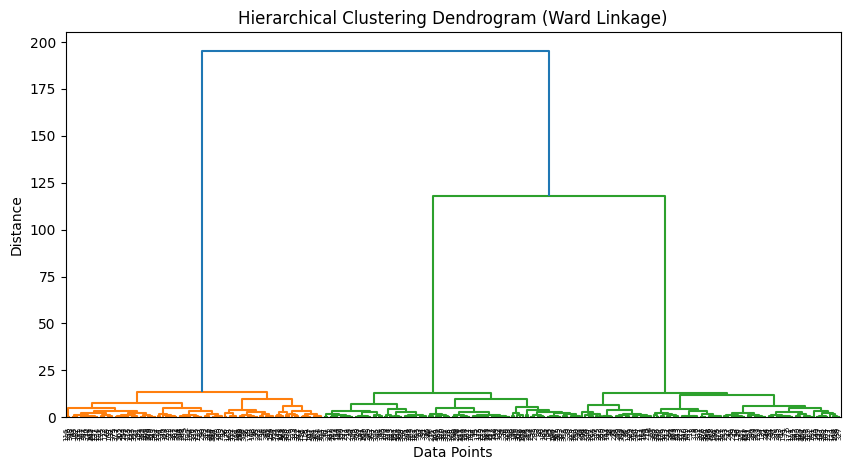

In [39]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X, method='ward', metric='euclidean')

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

#### How to Interpret the Dendrogram

- Each leaf → one data point

- Each merge → two clusters being combined

- The height of a merge → distance between clusters

#### Choosing the Number of Clusters

- Draw a horizontal line across the dendrogram

- Count how many vertical branches it cuts

### Rule of thumb:

Choose the cut where there is a large vertical gap
(big jump in distance before clusters merge)

## Important Considerations for Agglomerative Clustering

### When to Use Agglomerative Clustering

**- Does not require specifying K upfront:**  
Hierarchical clustering can build a full hierarchy of clusters and allows you to decide the number of clusters later by cutting the dendrogram at a chosen level.

**- Works well with small to medium datasets:**  
Because it computes distances between many pairs of points, it is more suitable when the dataset is not extremely large.

**- Useful for understanding data structure:**  
The dendrogram provides a visual explanation of how data points are grouped, making it useful for exploratory analysis.

**- Flexible cluster shapes (linkage):**  
Different linkage methods allow the algorithm to capture different types of cluster structures


### Limitations of Agglomerative Clustering

**- Computationally expensive:**  
Agglomerative clustering has higher time and memory complexity, making it impractical for very large datasets

**- Sensitive to noise and outliers:**  
Outliers can form their own clusters or distort the merging process

**- Early decisions cannot be undone:**  
Once two clusters are merged, the algorithm cannot reconsider that decision later, which may lead to suboptimal clusters

**- Results depend heavily on linkage choice:**  
Different linkage methods can produce very different clusterings, so parameter selection is critical

## Task 2A: Agglomerative Clustering

In this task, you will apply **Agglomerative Clustering** to `CC GENERAL` dataset and follow **the same methodology** used in the previous clustering lab

## **1. Exploratory Data Analysis (EDA)**

In [40]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\shwae\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [41]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage

In [42]:
df = pd.read_csv('CC GENERAL.csv')

df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [43]:
# Basic information
print("Dataset Shape:", df.shape)
print("\nData Types:\n", df.dtypes)

Dataset Shape: (8950, 18)

Data Types:
 CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object


In [44]:
# Summary statistics
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [45]:
# Check missing values
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


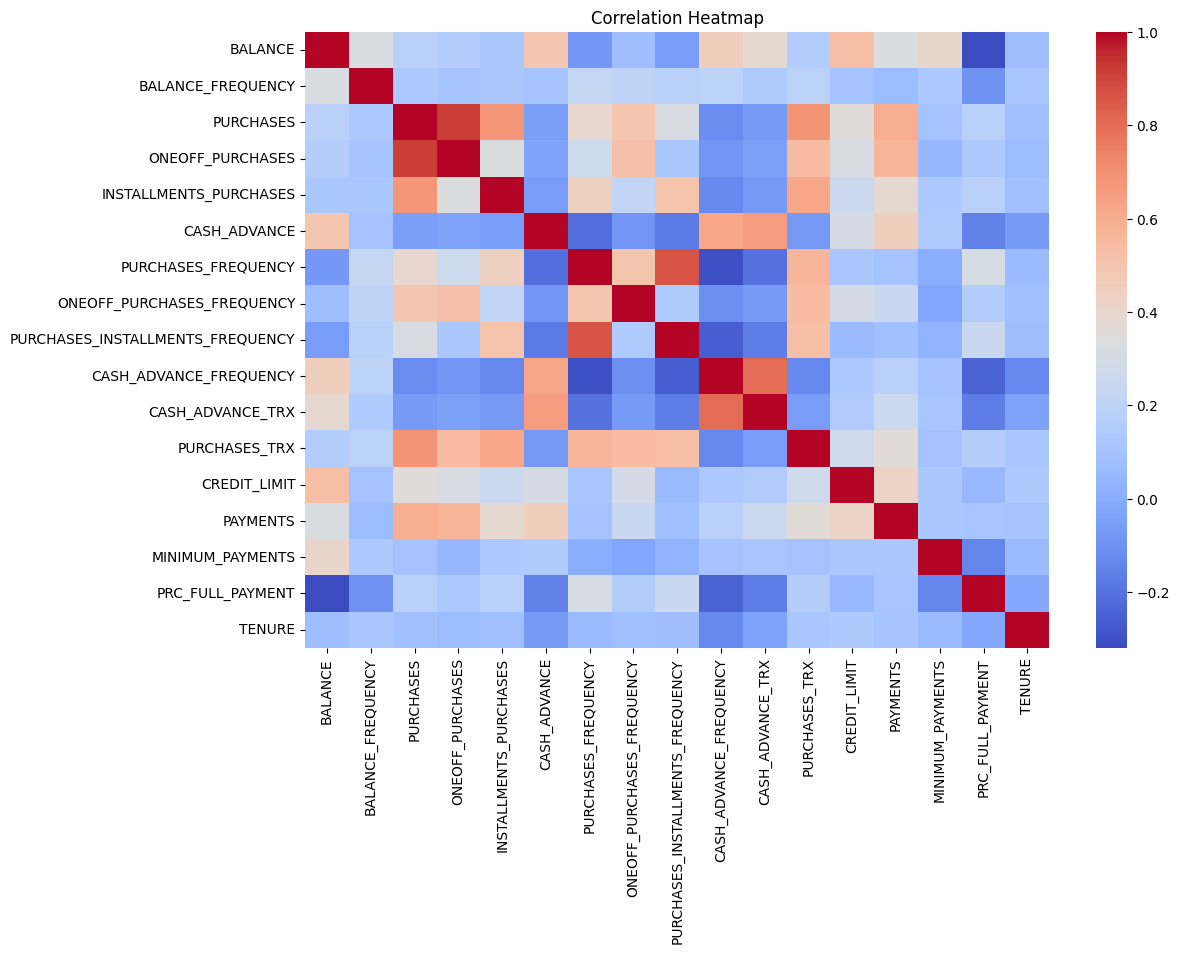

In [46]:
# Correlation heatmap (numeric columns only)

numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

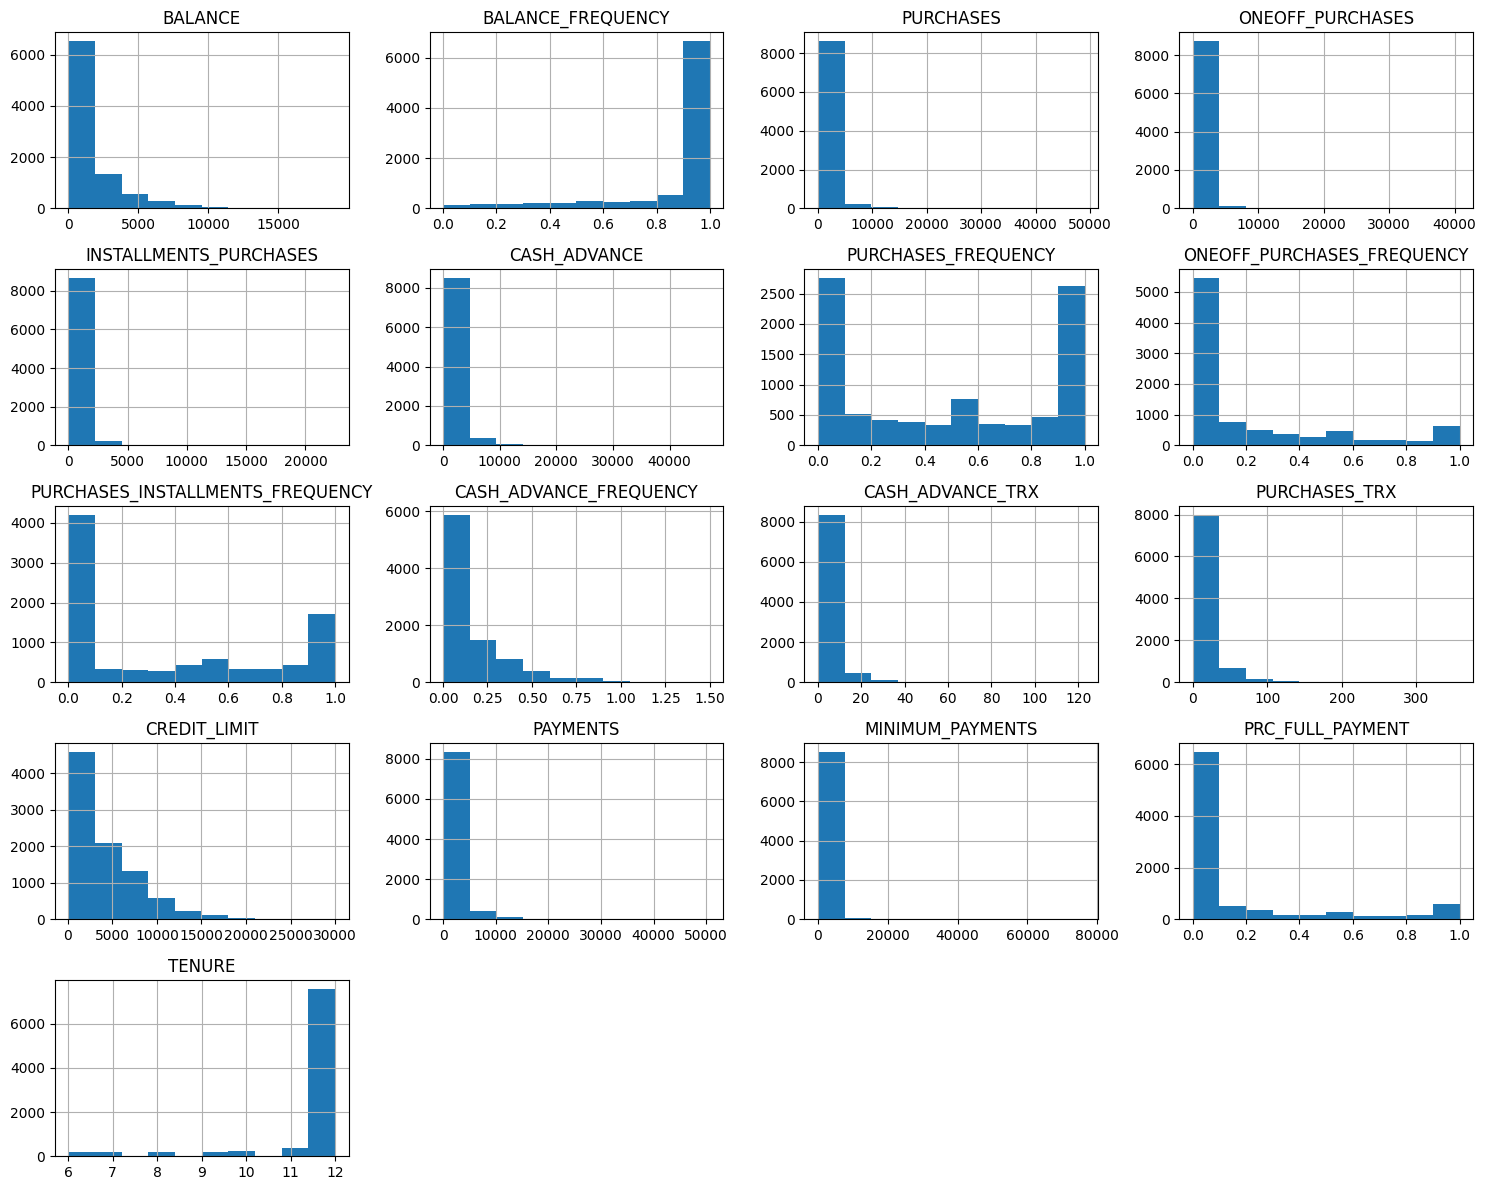

In [47]:
# Histograms
df.hist(figsize=(15,12))
plt.tight_layout()
plt.show()

## **2. Data Preparation**

In [48]:
# Drop customer ID column if exists
if 'CUST_ID' in df.columns:
    df = df.drop(columns=['CUST_ID'])

# Handle missing values (fill with mean)
df = df.fillna(df.mean())

df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [49]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("Scaled Data Shape:", X_scaled.shape)

Scaled Data Shape: (8950, 17)


## **3. Apply Agglomerative Clustering**

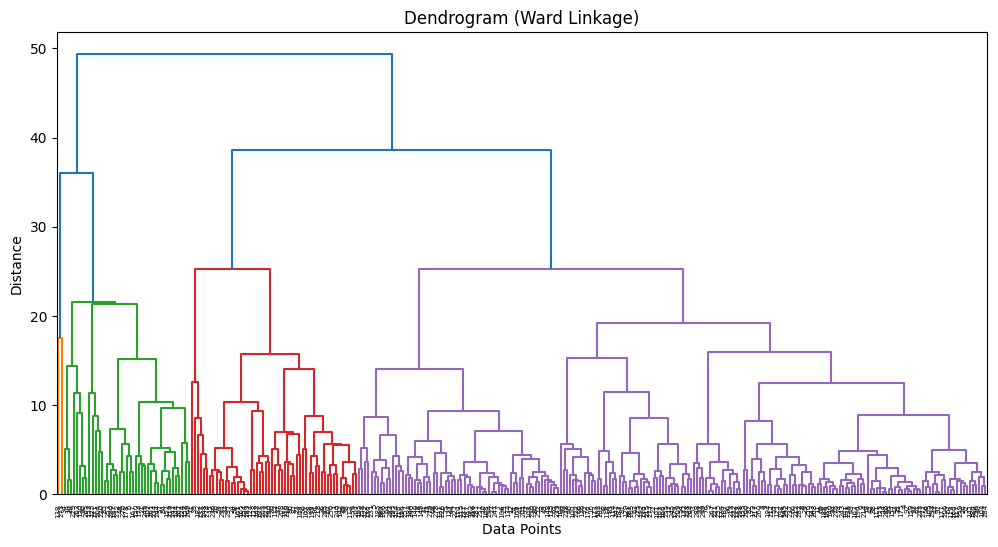

In [50]:
# Use a sample if dataset is large
sample_size = 300
X_sample = X_scaled[:sample_size]

linked = linkage(X_sample, method='ward')

plt.figure(figsize=(12,6))
dendrogram(linked)
plt.title("Dendrogram (Ward Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

the dendogram shows that they are 4 clusters, or maybe 3bi

In [59]:
cluster_range = range(2, 7)
linkage_methods = ['ward', 'complete', 'average', 'single']

results = []

for linkage_method in linkage_methods:
    print(f"\n=== Linkage Method: {linkage_method} ===")

    for k in cluster_range:

        if linkage_method == 'ward':
            model = AgglomerativeClustering(
                n_clusters=k,
                linkage=linkage_method,
                metric='euclidean'
            )
        else:
            model = AgglomerativeClustering(
                n_clusters=k,
                linkage=linkage_method,
                metric='euclidean'
            )

        labels = model.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)

        results.append({
            "Linkage": linkage_method,
            "Clusters": k,
            "Silhouette": sil
        })

        print(f"Clusters: {k}, Silhouette Score: {sil:.4f}")


=== Linkage Method: ward ===
Clusters: 2, Silhouette Score: 0.1775
Clusters: 3, Silhouette Score: 0.1731
Clusters: 4, Silhouette Score: 0.1547
Clusters: 5, Silhouette Score: 0.1581
Clusters: 6, Silhouette Score: 0.1734

=== Linkage Method: complete ===
Clusters: 2, Silhouette Score: 0.7866
Clusters: 3, Silhouette Score: 0.7863
Clusters: 4, Silhouette Score: 0.7793
Clusters: 5, Silhouette Score: 0.6599
Clusters: 6, Silhouette Score: 0.6598

=== Linkage Method: average ===
Clusters: 2, Silhouette Score: 0.8408
Clusters: 3, Silhouette Score: 0.8126
Clusters: 4, Silhouette Score: 0.8081
Clusters: 5, Silhouette Score: 0.7857
Clusters: 6, Silhouette Score: 0.7565

=== Linkage Method: single ===
Clusters: 2, Silhouette Score: 0.8408
Clusters: 3, Silhouette Score: 0.8380
Clusters: 4, Silhouette Score: 0.8121
Clusters: 5, Silhouette Score: 0.8116
Clusters: 6, Silhouette Score: 0.7703


In [60]:
results_df = pd.DataFrame(results)

print("\n=== Comparison of Linkage Methods ===")
print(results_df)


=== Comparison of Linkage Methods ===
     Linkage  Clusters  Silhouette
0       ward         2    0.177545
1       ward         3    0.173110
2       ward         4    0.154709
3       ward         5    0.158069
4       ward         6    0.173356
5   complete         2    0.786555
6   complete         3    0.786309
7   complete         4    0.779261
8   complete         5    0.659927
9   complete         6    0.659815
10   average         2    0.840813
11   average         3    0.812602
12   average         4    0.808091
13   average         5    0.785699
14   average         6    0.756536
15    single         2    0.840813
16    single         3    0.837991
17    single         4    0.812116
18    single         5    0.811635
19    single         6    0.770331


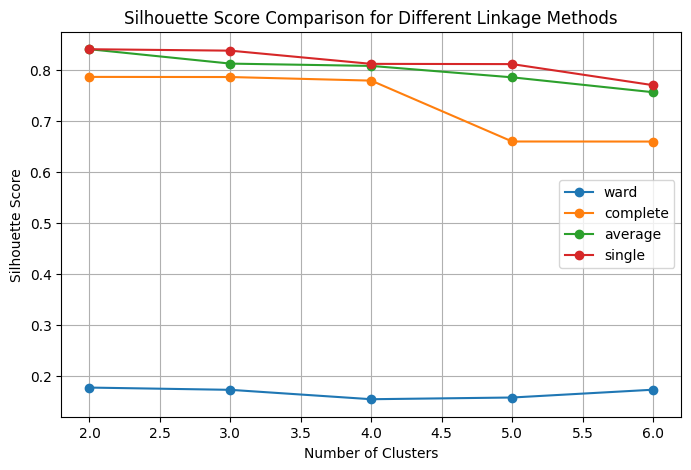

In [61]:
plt.figure(figsize=(8,5))

for linkage_method in linkage_methods:
    subset = results_df[results_df['Linkage'] == linkage_method]
    plt.plot(subset['Clusters'], subset['Silhouette'], marker='o', label=linkage_method)

plt.title("Silhouette Score Comparison for Different Linkage Methods")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.legend()
plt.grid(True)
plt.show()

## **4. Visualize the Clustering Results**

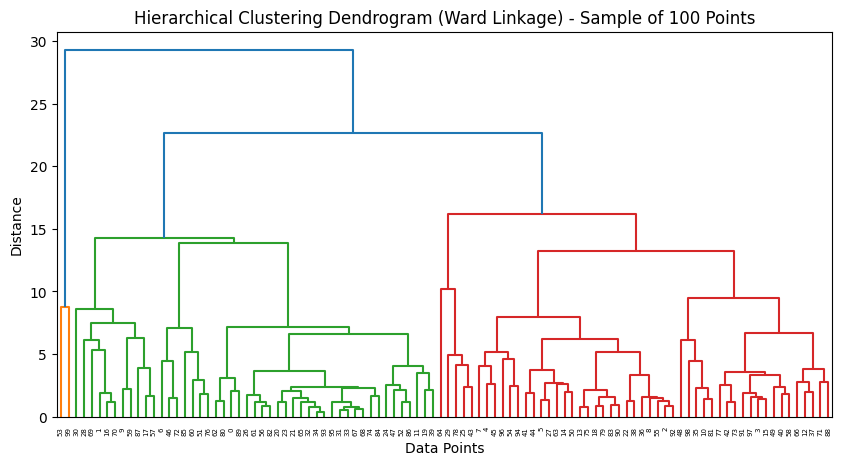

In [53]:
# Plot dendrogram for a sample of the data (full dataset is too large)
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Sample 100 points for dendrogram visualization
np.random.seed(42)
sample_indices = np.random.choice(X_scaled.shape[0], size=100, replace=False)
X_sample = X_scaled[sample_indices]

Z = linkage(X_sample, method='ward', metric='euclidean')

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage) - Sample of 100 Points")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

## **5. Evaluate the Clustering**

In [65]:
# Choose optimal number of clusters (let's use the best from silhouette score)
optimal_k = 2
print(f"Optimal Number of Clusters: {optimal_k}")

# Apply final model with optimal clusters
final_model = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
final_labels = final_model.fit_predict(X_scaled)

# Calculate evaluation metrics
sil_score = silhouette_score(X_scaled, final_labels)
ch_score = calinski_harabasz_score(X_scaled, final_labels)
db_score = davies_bouldin_score(X_scaled, final_labels)

print(f"\n=== Clustering Evaluation Metrics ===")
print(f"Silhouette Score: {sil_score:.4f} (Range: -1 to 1, Higher is Better)")
print(f"Calinski-Harabasz Index: {ch_score:.4f} (Higher is Better)")
print(f"Davies-Bouldin Index: {db_score:.4f} (Lower is Better)")

# Interpretation
print(f"\n=== Interpretation ===")
if sil_score > 0.5:
    print("✓ Silhouette Score indicates well-separated, cohesive clusters")
elif sil_score > 0.25:
    print("✓ Silhouette Score indicates reasonably separated clusters")
else:
    print("⚠ Silhouette Score suggests clusters are overlapping")

if db_score < 1:
    print("✓ Davies-Bouldin Index indicates good cluster separation")
else:
    print("⚠ Davies-Bouldin Index suggests clusters could be better separated")

Optimal Number of Clusters: 2

=== Clustering Evaluation Metrics ===
Silhouette Score: 0.1775 (Range: -1 to 1, Higher is Better)
Calinski-Harabasz Index: 1424.7357 (Higher is Better)
Davies-Bouldin Index: 2.0626 (Lower is Better)

=== Interpretation ===
⚠ Silhouette Score suggests clusters are overlapping
⚠ Davies-Bouldin Index suggests clusters could be better separated



=== Cluster Sizes ===
Cluster
0    5532
1    3418
Name: count, dtype: int64

=== Cluster Statistics ===
         BALANCE          BALANCE_FREQUENCY       PURCHASES           \
            mean      std              mean   std      mean      std   
Cluster                                                                
0        1652.80  2175.73              0.82  0.28    328.38   595.80   
1        1421.52  1910.98              0.98  0.07   2095.40  3074.25   

        ONEOFF_PURCHASES          INSTALLMENTS_PURCHASES           
                    mean      std                   mean      std  
Cluster                                                            
0                 202.27   490.32                  126.4   300.69  
1                1223.92  2486.23                  871.8  1285.29  


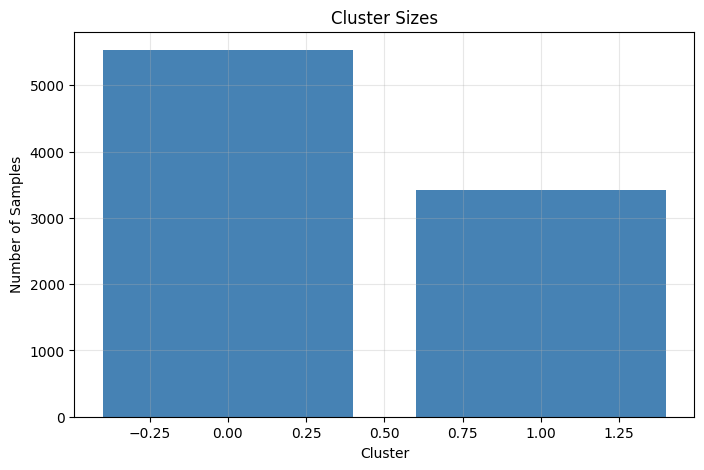

In [66]:
# Analyze cluster characteristics
df_with_clusters = df.copy()
df_with_clusters['Cluster'] = final_labels

print("\n=== Cluster Sizes ===")
print(df_with_clusters['Cluster'].value_counts().sort_index())

print("\n=== Cluster Statistics ===")
cluster_stats = df_with_clusters.groupby('Cluster').agg(['mean', 'std']).round(2)
print(cluster_stats.iloc[:, :10])  # Show first 10 features

# Visualize cluster sizes
plt.figure(figsize=(8, 5))
cluster_counts = df_with_clusters['Cluster'].value_counts().sort_index()
plt.bar(cluster_counts.index, cluster_counts.values, color='steelblue')
plt.title('Cluster Sizes')
plt.xlabel('Cluster')
plt.ylabel('Number of Samples')
plt.grid(True, alpha=0.3)
plt.show()


=== All Metrics Comparison ===
 Clusters  Silhouette  Calinski-Harabasz  Davies-Bouldin
        2    0.177545        1424.735667        2.062597
        3    0.173110        1270.503917        1.797923
        4    0.154709        1255.604855        1.776164
        5    0.158069        1161.990892        1.588442
        6    0.173356        1119.881350        1.524655


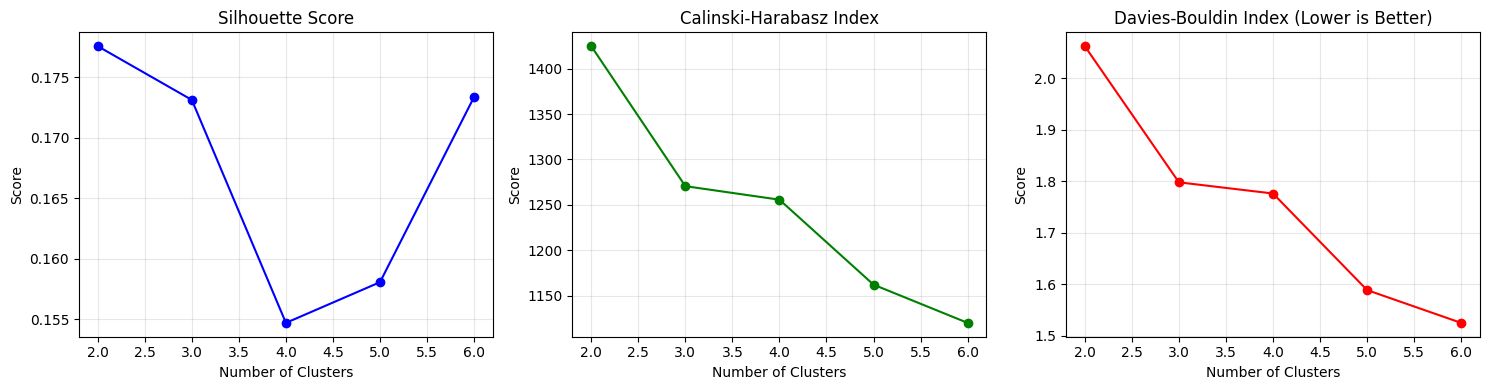

In [67]:
# Compare all metrics across different numbers of clusters
all_metrics = []
for k in cluster_range:
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    all_metrics.append({'Clusters': k, 'Silhouette': sil, 'Calinski-Harabasz': ch, 'Davies-Bouldin': db})

metrics_df = pd.DataFrame(all_metrics)
print("\n=== All Metrics Comparison ===")
print(metrics_df.to_string(index=False))

# Plot all metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(metrics_df['Clusters'], metrics_df['Silhouette'], marker='o', color='blue')
axes[0].set_title('Silhouette Score')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Score')
axes[0].grid(True, alpha=0.3)

axes[1].plot(metrics_df['Clusters'], metrics_df['Calinski-Harabasz'], marker='o', color='green')
axes[1].set_title('Calinski-Harabasz Index')
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Score')
axes[1].grid(True, alpha=0.3)

axes[2].plot(metrics_df['Clusters'], metrics_df['Davies-Bouldin'], marker='o', color='red')
axes[2].set_title('Davies-Bouldin Index (Lower is Better)')
axes[2].set_xlabel('Number of Clusters')
axes[2].set_ylabel('Score')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

LINKAGE = AVERAGE

In [68]:
# Choose optimal number of clusters (let's use the best from silhouette score)
optimal_k = 2
print(f"Optimal Number of Clusters: {optimal_k}")

# Apply final model with optimal clusters
final_model = AgglomerativeClustering(n_clusters=optimal_k, linkage='average')
final_labels = final_model.fit_predict(X_scaled)

# Calculate evaluation metrics
sil_score = silhouette_score(X_scaled, final_labels)
ch_score = calinski_harabasz_score(X_scaled, final_labels)
db_score = davies_bouldin_score(X_scaled, final_labels)

print(f"\n=== Clustering Evaluation Metrics ===")
print(f"Silhouette Score: {sil_score:.4f} (Range: -1 to 1, Higher is Better)")
print(f"Calinski-Harabasz Index: {ch_score:.4f} (Higher is Better)")
print(f"Davies-Bouldin Index: {db_score:.4f} (Lower is Better)")

# Interpretation
print(f"\n=== Interpretation ===")
if sil_score > 0.5:
    print("✓ Silhouette Score indicates well-separated, cohesive clusters")
elif sil_score > 0.25:
    print("✓ Silhouette Score indicates reasonably separated clusters")
else:
    print("⚠ Silhouette Score suggests clusters are overlapping")

if db_score < 1:
    print("✓ Davies-Bouldin Index indicates good cluster separation")
else:
    print("⚠ Davies-Bouldin Index suggests clusters could be better separated")

Optimal Number of Clusters: 2

=== Clustering Evaluation Metrics ===
Silhouette Score: 0.8408 (Range: -1 to 1, Higher is Better)
Calinski-Harabasz Index: 60.3684 (Higher is Better)
Davies-Bouldin Index: 0.1103 (Lower is Better)

=== Interpretation ===
✓ Silhouette Score indicates well-separated, cohesive clusters
✓ Davies-Bouldin Index indicates good cluster separation



=== Cluster Sizes ===
Cluster
0    8949
1       1
Name: count, dtype: int64

=== Cluster Statistics ===
          BALANCE         BALANCE_FREQUENCY       PURCHASES           \
             mean     std              mean   std      mean      std   
Cluster                                                                
0         1563.43  2079.3              0.88  0.24   1003.27  2136.75   
1        10905.05     NaN              1.00   NaN    431.93      NaN   

        ONEOFF_PURCHASES          INSTALLMENTS_PURCHASES          
                    mean      std                   mean     std  
Cluster                                                           
0                 592.49  1659.97                 411.08  904.39  
1                 133.50      NaN                 298.43     NaN  


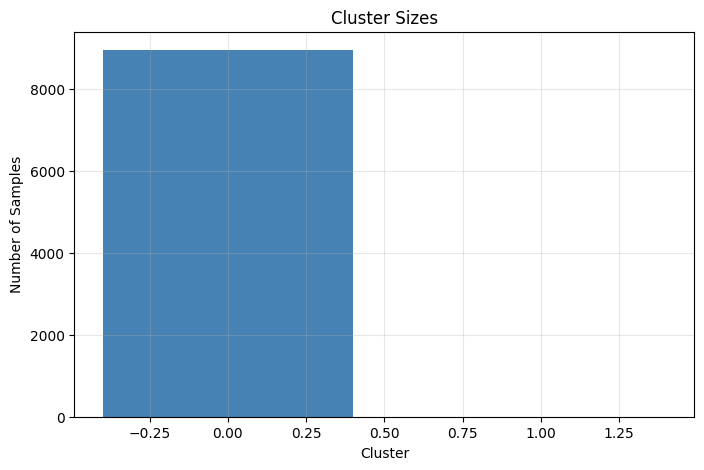

In [69]:
# Analyze cluster characteristics
df_with_clusters = df.copy()
df_with_clusters['Cluster'] = final_labels

print("\n=== Cluster Sizes ===")
print(df_with_clusters['Cluster'].value_counts().sort_index())

print("\n=== Cluster Statistics ===")
cluster_stats = df_with_clusters.groupby('Cluster').agg(['mean', 'std']).round(2)
print(cluster_stats.iloc[:, :10])  # Show first 10 features

# Visualize cluster sizes
plt.figure(figsize=(8, 5))
cluster_counts = df_with_clusters['Cluster'].value_counts().sort_index()
plt.bar(cluster_counts.index, cluster_counts.values, color='steelblue')
plt.title('Cluster Sizes')
plt.xlabel('Cluster')
plt.ylabel('Number of Samples')
plt.grid(True, alpha=0.3)
plt.show()

## **6. Explain whether the clustering quality and justify your reasoning**

when i used the ward, the silhouette was very low. in average the silhouette score was high but it grouped all the data into one cluster. this suggestes that maybe the dataset wasnt handled correctly, or this clustering method is not suitable for this dataset